<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/alex/RA1_LAB1/Experiencia_2_Laboratorio_N%C2%B01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Experiencia 2: Monitor de calidad de aire en espacios de trabajo

## Inteligencia Computacional — IC415 | RA1 Laboratorio N° 1

**Grupo 8:** — Alex Nahuel Acosta, Santiago Daniel Bareiro, Agustín Marcelo Borges

**Fecha:** — 19/04/2026

### Contexto del problema

Una empresa consultora en salud ocupacional está desarrollando un dispositivo IoT de bajo costo para
monitorear la calidad del aire en espacios de trabajo cerrados: cocinas industriales, laboratorios, depósitos
con productos de limpieza y oficinas. El dispositivo incluye una matriz de seis sensores de gas y debe
clasificar de forma autónoma la situación del ambiente para activar alertas o sistemas de ventilación
forzada.

**Dataset empleado:** `datos_adl.csv`, posee 1845 muestras medidas por todos los sensores. Variable objetivo: `situación`.

---

### Estructura del notebook

1. Análisis Exploratorio de Datos (EDA)
2. Entrenamiento del mejor modelo
3. Ablación de sensores

In [3]:
# @title Importación, visualización, manipulación de datos
import pandas as pd
import sys
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import pickle
import time
import warnings
from sklearn.model_selection import (train_test_split, cross_val_score,
                                      StratifiedKFold, GridSearchCV)
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, accuracy_score, balanced_accuracy_score,
                              ConfusionMatrixDisplay, make_scorer, recall_score)
from sklearn.feature_selection import mutual_info_classif, RFECV
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
import time
from itertools import combinations

---
## 1. Análisis Exploratorio de Datos (EDA)



In [4]:
# Archivos pueden arrastrarse al área de trabajo o procesarse en local

# Versión en Línea
!wget https://raw.githubusercontent.com/Santibareiro27/Inteligencia-Computacional/main/RA1_LAB1/datos_adl.csv
# Lectura del dataset
dataset_adl = pd.read_csv("datos_adl.csv")

--2026-04-19 23:05:12--  https://raw.githubusercontent.com/Santibareiro27/Inteligencia-Computacional/main/RA1_LAB1/datos_adl.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 54724 (53K) [text/plain]
Saving to: ‘datos_adl.csv’

datos_adl.csv       100%[===================>]  53.44K  --.-KB/s    in 0.001s  

2026-04-19 23:05:12 (78.0 MB/s) - ‘datos_adl.csv’ saved [54724/54724]



In [5]:
dataset_adl

,MQ2,MQ9,MQ135,MQ137,MQ138,MG-811,Situacion
0,670,696,1252,1720,1321,2431,4
1,641,674,1156,1652,1410,2433,4
2,642,646,1159,1643,1455,2361,4
3,640,590,1105,1608,1459,2427,4
4,616,627,1192,1637,1466,2447,4
...,...,...,...,...,...,...,...
1840,862,826,1564,1768,1540,2037,4
1841,917,821,1571,1779,1543,2008,4
1842,925,832,1582,1776,1545,1989,4
1843,928,840,1587,1787,1538,1986,4


In [6]:
dataset_adl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1845 entries, 0 to 1844
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   MQ2        1845 non-null   int64
 1   MQ9        1845 non-null   int64
 2   MQ135      1845 non-null   int64
 3   MQ137      1845 non-null   int64
 4   MQ138      1845 non-null   int64
 5   MG-811     1845 non-null   int64
 6   Situacion  1845 non-null   int64
dtypes: int64(7)
memory usage: 101.0 KB


No hay valores nulos, todos los datos son de tipo entero, la dataset pesa 101 KB.

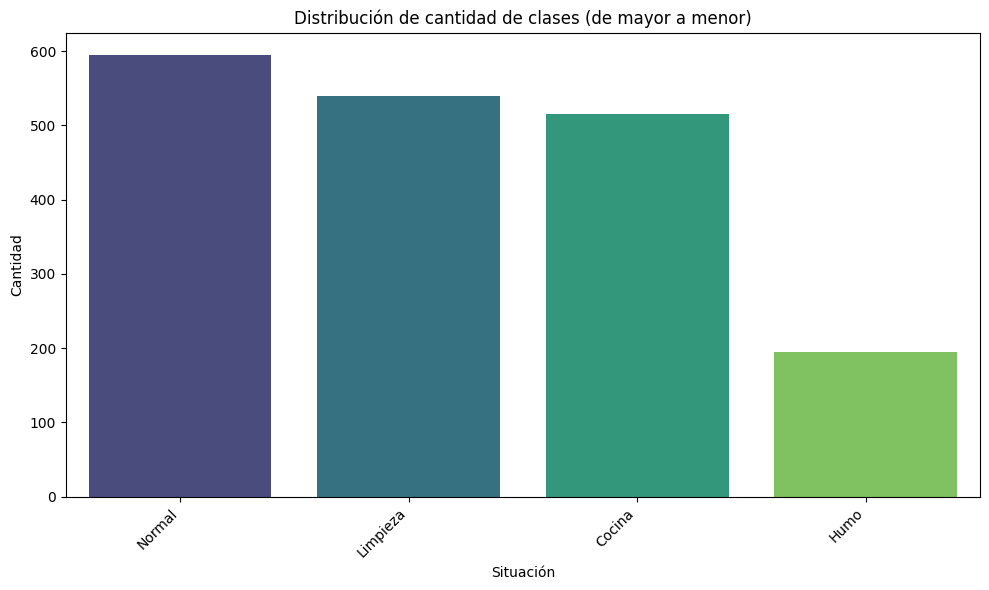

In [7]:
situacion_counts = dataset_adl['Situacion'].value_counts().sort_values(ascending=False)

situacion_labels = {
    1: 'Normal',
    2: 'Cocina',
    3: 'Humo',
    4: 'Limpieza'
}

# Mapea las situaciones numéricas a sus etiquetas descriptivas para la gráfica
labels = [situacion_labels[s] for s in situacion_counts.index]

plt.figure(figsize=(10, 6))
sns.barplot(x=labels, y=situacion_counts.values, hue=labels, palette='viridis', legend=False)
plt.title('Distribución de cantidad de clases (de mayor a menor)')
plt.xlabel('Situación')
plt.ylabel('Cantidad')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [8]:
total_instances = situacion_counts.sum()

percentages = (situacion_counts / total_instances) * 100

print("Porcentaje de cada clase:")
for situacion_id, count in situacion_counts.items():
    label = situacion_labels.get(situacion_id, f'Situacion {situacion_id}')
    percentage = percentages[situacion_id]
    print(f"- {label}: {percentage:.2f}%")

Porcentaje de cada clase:
- Normal: 32.25%
- Limpieza: 29.27%
- Cocina: 27.91%
- Humo: 10.57%


Hay un claro desbalance de clases, la de humo posee 3 veces menos muestras que la normal.

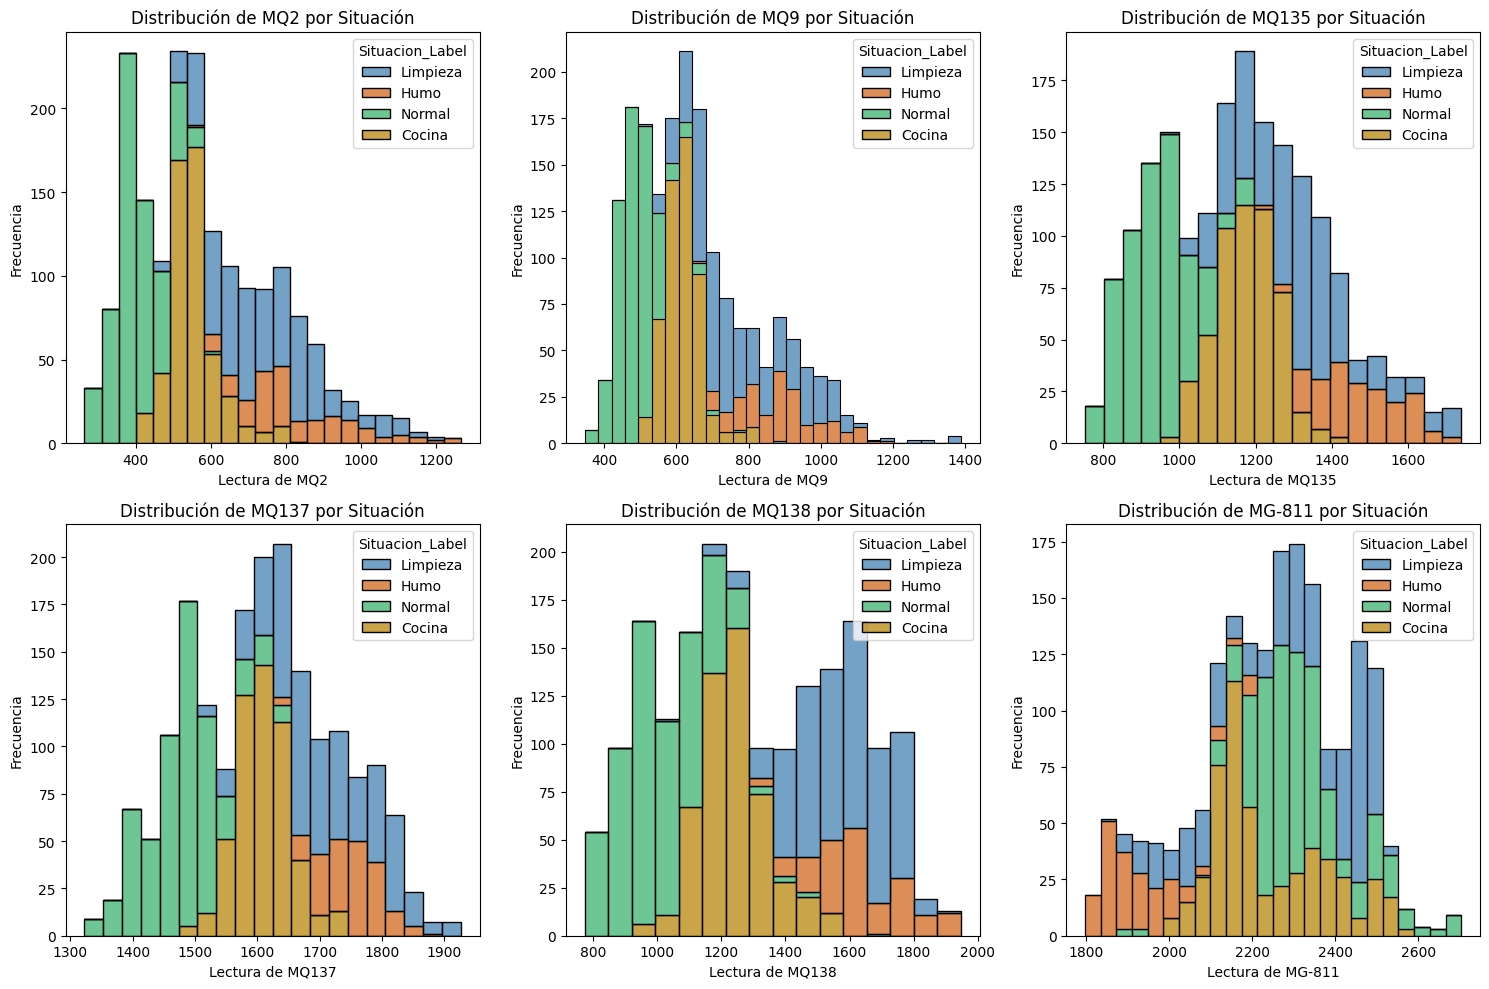

In [9]:
if 'dataset_adl' not in globals():
    try:
        dataset_adl = pd.read_csv("datos_adl.csv")
    except FileNotFoundError:
        print("Error: 'datos_adl.csv' no encontrado. Asegúrate de que el archivo esté descargado o especifica la ruta correcta.")
        raise

sensor_columns = ['MQ2', 'MQ9', 'MQ135', 'MQ137', 'MQ138', 'MG-811']


fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

dataset_adl_labeled = dataset_adl.copy()
dataset_adl_labeled['Situacion_Label'] = dataset_adl_labeled['Situacion'].map(situacion_labels)

custom_palette = {
    'Humo': 'chocolate',
    'Limpieza': 'steelblue',
    'Cocina': 'darkgoldenrod',
    'Normal': 'mediumseagreen'
}

for i, sensor in enumerate(sensor_columns):
    # Grafica el histograma para cada sensor, con el tono basado en 'Situacion_Label' y la paleta personalizada
    sns.histplot(data=dataset_adl_labeled, x=sensor, hue='Situacion_Label', multiple='stack', ax=axes[i], kde=False, palette=custom_palette)
    axes[i].set_title(f'Distribución de {sensor} por Situación')
    axes[i].set_xlabel(f'Lectura de {sensor}')
    axes[i].set_ylabel('Frecuencia')


plt.tight_layout()
plt.show()

Los sensores operan en rangos numéricos distintos (MQ137 y MQ138 rondan 1600–1800, MQ2 y MQ9 rondan 600–700), y hay sensores que discriminan mejor ciertas situaciones: MQ2 y MQ9 se disparan ante humo, MQ137 y MQ138 ante limpieza. Esto deberá tenerse en cuenta al seleccionar y configurar el modelo.

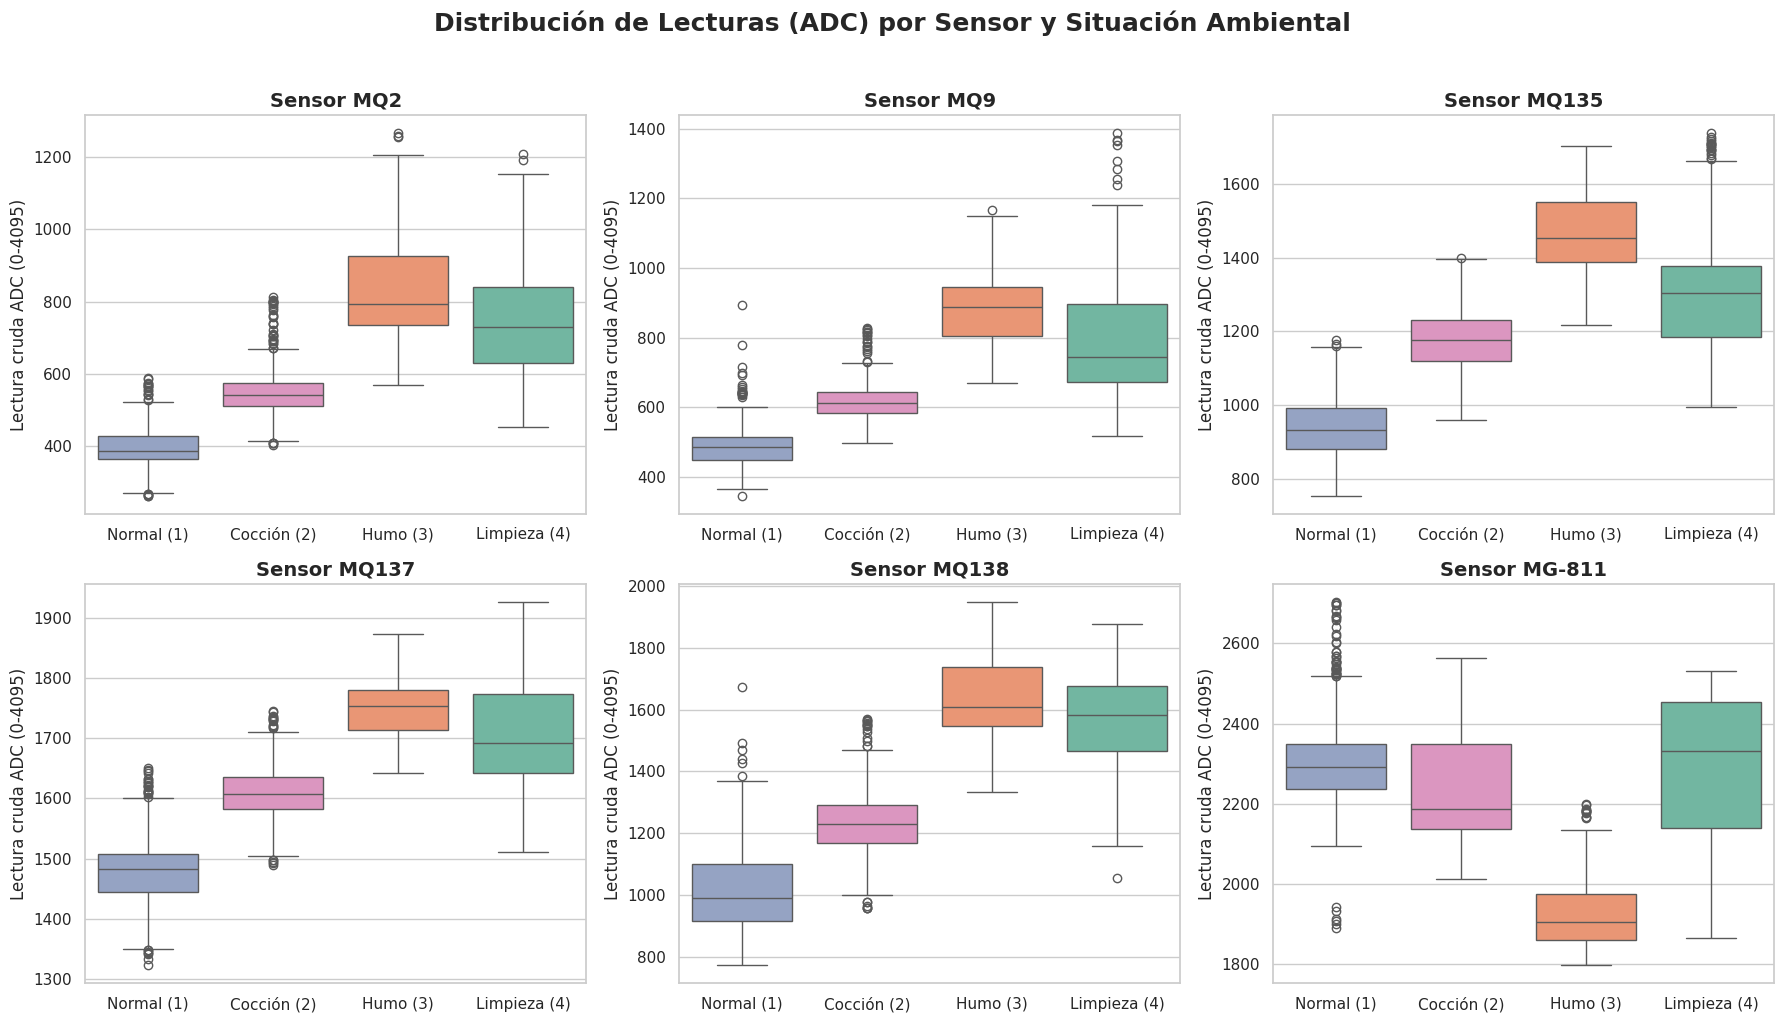

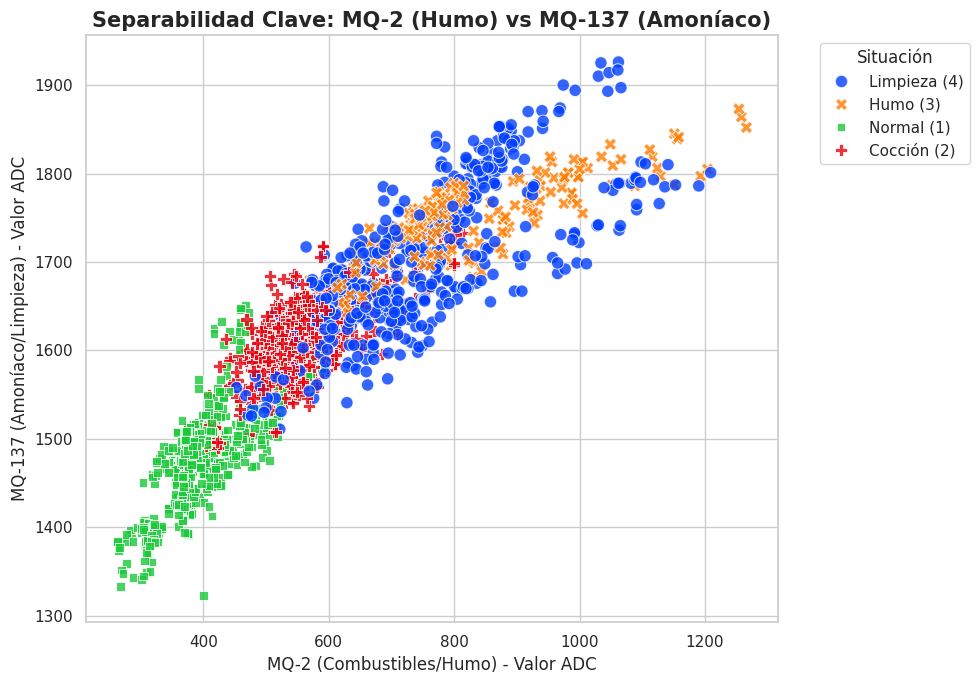

In [10]:
# 1. Mapear las etiquetas numéricas a texto para que los gráficos sean autoexplicativos
etiquetas_situacion = {
    1: 'Normal (1)',
    2: 'Cocción (2)',
    3: 'Humo (3)',
    4: 'Limpieza (4)'
}

# Ensure dataset_adl is loaded
if 'dataset_adl' not in globals():
    try:
        dataset_adl = pd.read_csv("datos_adl.csv")
    except FileNotFoundError:
        print("Error: 'datos_adl.csv' no encontrado. Asegúrate de que el archivo esté descargado o especifica la ruta correcta.")
        raise

dataset_adl['Situacion_Nombre'] = dataset_adl['Situacion'].map(etiquetas_situacion)
orden_clases = ['Normal (1)', 'Cocción (2)', 'Humo (3)', 'Limpieza (4)']

# 2. Configurar el estilo de Seaborn
sns.set_theme(style="whitegrid")

# ==============================================================================
# GRÁFICO 1: Boxplots de cada sensor (Evidencia de sensibilidad)
# ==============================================================================
sensores = ['MQ2', 'MQ9', 'MQ135', 'MQ137', 'MQ138', 'MG-811']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribución de Lecturas (ADC) por Sensor y Situación Ambiental', fontsize=18, fontweight='bold', y=1.02)

for i, sensor in enumerate(sensores):
    row = i // 3
    col = i % 3

    # Crear el boxplot
    sns.boxplot(
        data=dataset_adl,
        x='Situacion_Nombre',
        y=sensor,
        ax=axes[row, col],
        hue='Situacion_Nombre', # Añadido para eliminar la advertencia
        palette='Set2',
        order=orden_clases,
        legend=False # Añadido para eliminar la advertencia y evitar legendas duplicadas
    )

    axes[row, col].set_title(f'Sensor {sensor}', fontsize=14, fontweight='bold')
    axes[row, col].set_xlabel('')
    axes[row, col].set_ylabel('Lectura cruda ADC (0-4095)')

plt.tight_layout()
plt.show()

# ==============================================================================
# GRÁFICO 2: Scatter plot de Separabilidad (Humo vs Limpieza)
# ==============================================================================
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=dataset_adl,
    x='MQ2',
    y='MQ137',
    hue='Situacion_Nombre',
    palette='bright',
    style='Situacion_Nombre',
    s=80,
    alpha=0.8
)

plt.title('Separabilidad Clave: MQ-2 (Humo) vs MQ-137 (Amoníaco)', fontsize=15, fontweight='bold')
plt.xlabel('MQ-2 (Combustibles/Humo) - Valor ADC', fontsize=12)
plt.ylabel('MQ-137 (Amoníaco/Limpieza) - Valor ADC', fontsize=12)
plt.legend(title='Situación', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Las boxplots terminan de corroborar que sensores se destacan para ciertas clases. El scatter plot muestra que las clases forman agrupamientos bien diferenciados en el espacio de features, lo que sugiere que modelos basados en fronteras geométricas (KNN, árbol de decisión) podrían rendir bien.

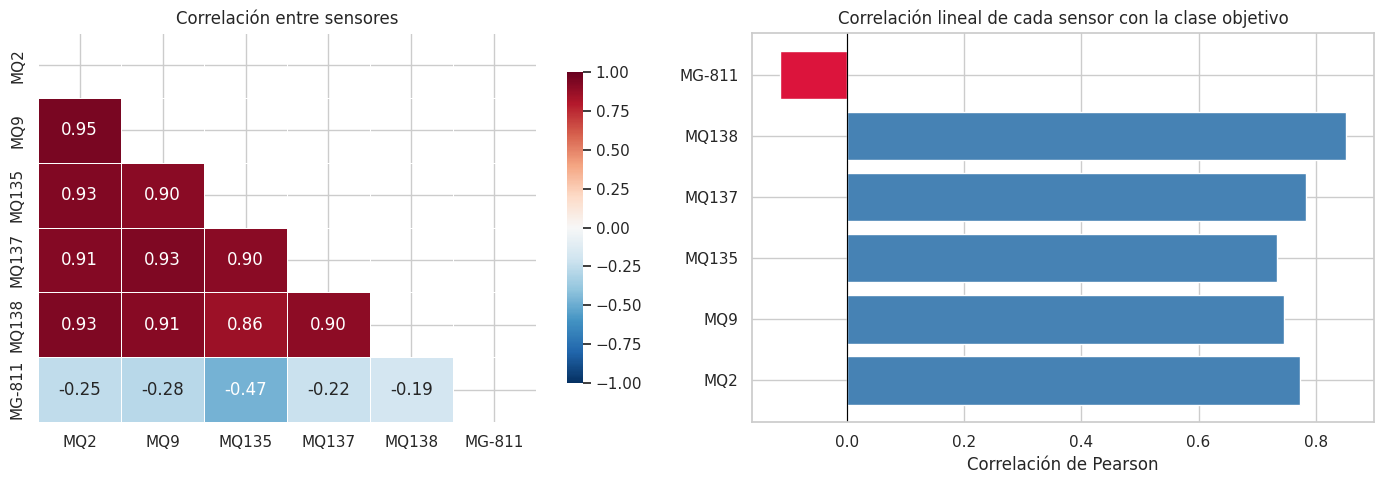

Correlaciones entre sensores MQ:
         MQ2    MQ9  MQ135  MQ137  MQ138
MQ2    1.000  0.947  0.928  0.915  0.934
MQ9    0.947  1.000  0.904  0.934  0.909
MQ135  0.928  0.904  1.000  0.900  0.858
MQ137  0.915  0.934  0.900  1.000  0.896
MQ138  0.934  0.909  0.858  0.896  1.000


In [11]:
sensores = ["MQ2", "MQ9", "MQ135", "MQ137", "MQ138", "MG-811"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlación completa
corr = dataset_adl[sensores].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, mask=mask,
            ax=axes[0], linewidths=0.5, cbar_kws={"shrink": 0.8})
axes[0].set_title("Correlación entre sensores", fontsize=12)

# Correlación con el target
corr_target = dataset_adl[sensores + ["Situacion"]].corr()["Situacion"].drop("Situacion")
colors_bar = ["steelblue" if v > 0 else "crimson" for v in corr_target]
axes[1].barh(corr_target.index, corr_target.values, color=colors_bar, edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Correlación lineal de cada sensor con la clase objetivo", fontsize=12)
axes[1].set_xlabel("Correlación de Pearson")

plt.tight_layout()
plt.show()

print("Correlaciones entre sensores MQ:")
mq_cols = ["MQ2", "MQ9", "MQ135", "MQ137", "MQ138"]
mq_corr = dataset_adl[mq_cols].corr()
print(mq_corr.round(3))

La familia de sensores MQ miden de forma similar, por eso tienen una alta correlación, y se observa como el MG recopila los datos de forma distinta.

### 1. Comparación de modelos

El scatter plot sugería que los mejores candidatos serían árbol de decisión y KNN. Tras evaluar todos los modelos, el árbol de decisión resultó el óptimo. Se remapearon las etiquetas por nivel de riesgo (Normal=1, Cocina=2, Limpieza=3, Humo=4) y se aplicó normalización StandardScaler. El modelo serializado ocupa ~17 KB en memoria, muy por debajo del límite de 256 KB del microcontrolador, e infiere en < 1 ms.

In [12]:
if 'dataset_adl' not in globals():
    try:
        dataset_adl = pd.read_csv("datos_adl.csv")
        print("Dataset 'datos_adl.csv' loaded as 'dataset_adl'.")
    except FileNotFoundError:
        print("Error: 'datos_adl.csv' not found. Please ensure the file is downloaded or specify the correct path.")
        raise
    except Exception as e:
        print(f"An error occurred while loading dataset_adl: {e}")
        raise

# Mapeo de la variable objetivo (Situacion)
# Original: 1 (normal), 2 (coccion), 3 (humo), 4 (limpieza)
# Nuevo: 1 (normal), 2 (cocina), 3 (limpieza), 4 (humo)
remapping = {1: 1, 2: 2, 4: 3, 3: 4}
dataset_adl['Situacion'] = dataset_adl['Situacion'].map(remapping)

# Comprobar la nueva distribución
print("--- NUEVA DISTRIBUCIÓN DE CLASES ---")
print(dataset_adl['Situacion'].value_counts().sort_index())

# Separar Features (X) y Target (y)
# Drop 'Situacion_Nombre' as it's a string representation of the target and not a feature
X = dataset_adl.drop(['Situacion', 'Situacion_Nombre'], axis=1, errors='ignore')
y = dataset_adl['Situacion']

# Train/Test Split (Estratificado)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Normalización (MinMaxScaler recomendado para IoT)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Probar múltiples modelos
models = {
    "Regresión Logística": LogisticRegression(max_iter=1000, random_state=42),
    "Árbol de Decisión": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM (Lineal)": SVC(kernel='linear', random_state=42),
    "SVM (RBF)": SVC(kernel='rbf', random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

results = []
for name, model in models.items():
    # Tiempo de entrenamiento
    start_train = time.time()
    model.fit(X_train_scaled, y_train)
    end_train = time.time()

    # Consumo de RAM del modelo entrenado (en Bytes, luego se convertirá a KB)
    ram_usage_bytes = sys.getsizeof(pickle.dumps(model))
    ram_usage_kb = ram_usage_bytes / 1024 # Convert to KB

    # Tiempo de inferencia
    start_pred = time.time()
    y_pred = model.predict(X_test_scaled)
    end_pred = time.time()

    # Métricas
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append({
        "Modelo": name,
        "Accuracy": round(acc, 4),
        "F1-Score": round(f1, 4),
        "T. Entrenamiento (s)": round(end_train - start_train, 5),
        "T. Inferencia (s)": round(end_pred - start_pred, 5),
        "RAM usada (KB)": round(ram_usage_kb, 2)
    })

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)

results_df['RAM <= 200KB'] = results_df['RAM usada (KB)'].apply(lambda x: '✔' if x <= 200 else '✖')

print("\n--- COMPARACIÓN DE MODELOS ---")
print(results_df.to_string(index=False))


--- NUEVA DISTRIBUCIÓN DE CLASES ---
Situacion
1    595
2    515
3    540
4    195
Name: count, dtype: int64

--- COMPARACIÓN DE MODELOS ---
             Modelo  Accuracy  F1-Score  T. Entrenamiento (s)  T. Inferencia (s)  RAM usada (KB) RAM <= 200KB
                KNN    0.9729    0.9729               0.00322            0.00394          101.30            ✔
      Random Forest    0.9593    0.9596               0.38235            0.01014         1866.78            ✖
          SVM (RBF)    0.9322    0.9322               0.02166            0.00980           38.60            ✔
  Árbol de Decisión    0.9322    0.9323               0.01223            0.00043           17.95            ✔
       SVM (Lineal)    0.8835    0.8840               0.01990            0.00630           50.55            ✔
Regresión Logística    0.8564    0.8566               0.03081            0.00041            0.96            ✔


Se remapearon las etiquetas de clase para ordenarlas por nivel de riesgo (Normal=1, Cocina=2, Limpieza=3, Humo=4), priorizando la detección de humo como clase de mayor criticidad. Se aplicó normalización StandardScaler como preprocesamiento previo al entrenamiento. El árbol de decisión serializado ocupa ~17 KB en memoria, muy por debajo del límite de 256 KB del microcontrolador, e infiere en < 1 ms.



---


## 2. Entrenamiento del mejor modelo

In [13]:
# Mapeo de la variable objetivo según nivel de alerta
remapping = {1: 1, 2: 2, 4: 3, 3: 4}
dataset_adl['Situacion'] = dataset_adl['Situacion'].map(remapping)

X = dataset_adl.drop(['Situacion', 'Situacion_Nombre'], axis=1)

y = dataset_adl['Situacion']
target_names = ['Normal (1)', 'Cocina (2)', 'Limpieza (3)', 'Humo (4)']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Normalización
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =====================================================================
# EXPERIMENTO 1: Árbol de Decisión con TODOS los sensores
# =====================================================================
dt_all = DecisionTreeClassifier(random_state=42)
dt_all.fit(X_train_scaled, y_train)

# Extraer Importancia de Variables del Árbol
importances = dt_all.feature_importances_
feature_names = X.columns
feat_imp_df = pd.DataFrame({'Sensor': feature_names, 'Importancia': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importancia', ascending=False)

print("--- IMPORTANCIA DE SENSORES (ÁRBOL DE DECISIÓN) ---")
print(feat_imp_df.to_string(index=False))

print("\n--- REPORTE 1: ÁRBOL CON TODOS LOS SENSORES ---")
print(classification_report(y_test, dt_all.predict(X_test_scaled), target_names=target_names))

# =====================================================================
# EXPERIMENTO 2: Eliminar MG-811 (Simulando dispositivo Low-Cost)
# =====================================================================
# El sensor MG-811 es la última columna (índice 5)
X_train_no_mg811 = np.delete(X_train_scaled, 5, axis=1)
X_test_no_mg811 = np.delete(X_test_scaled, 5, axis=1)

dt_no_mg811 = DecisionTreeClassifier(random_state=42)
dt_no_mg811.fit(X_train_no_mg811, y_train)

print("\n--- REPORTE 2: ÁRBOL SIN MG-811 (DESBALANCEADO) ---")
print(classification_report(y_test, dt_no_mg811.predict(X_test_no_mg811), target_names=target_names))

# =====================================================================
# EXPERIMENTO 3: Árbol SIN MG-811 pero con PENALIZACIÓN DE CLASE
# =====================================================================
# class_weight='balanced' obliga al árbol a prestarle mucha más atención
# matemática a las clases minoritarias (como el Humo)
dt_balanced = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt_balanced.fit(X_train_no_mg811, y_train)

print("\n--- REPORTE 3: ÁRBOL SIN MG-811 (BALANCEADO) ---")
print(classification_report(y_test, dt_balanced.predict(X_test_no_mg811), target_names=target_names))

--- IMPORTANCIA DE SENSORES (ÁRBOL DE DECISIÓN) ---
Sensor  Importancia
   MQ9     0.366626
 MQ138     0.280522
MG-811     0.144969
 MQ135     0.098041
 MQ137     0.071490
   MQ2     0.038352

--- REPORTE 1: ÁRBOL CON TODOS LOS SENSORES ---
              precision    recall  f1-score   support

  Normal (1)       0.99      0.97      0.98       119
  Cocina (2)       0.93      0.94      0.94       103
Limpieza (3)       0.82      0.85      0.84        39
    Humo (4)       0.91      0.91      0.91       108

    accuracy                           0.93       369
   macro avg       0.91      0.92      0.92       369
weighted avg       0.93      0.93      0.93       369


--- REPORTE 2: ÁRBOL SIN MG-811 (DESBALANCEADO) ---
              precision    recall  f1-score   support

  Normal (1)       1.00      0.94      0.97       119
  Cocina (2)       0.89      0.96      0.93       103
Limpieza (3)       0.82      0.79      0.81        39
    Humo (4)       0.92      0.92      0.92       108


El árbol de decisión identifica MQ9 y MQ138 como los sensores de mayor peso predictivo sobre el conjunto completo. Esta métrica mide utilidad en el conjunto global, no en combinaciones aisladas — por eso la selección final se valida mediante ablación exhaustiva en la sección siguiente.



---


## 3. Ablación de sensores

Se evaluaron combinaciones de sensores para encontrar el subconjunto de menor costo que preserva el Recall crítico de la clase Humo.

In [14]:
if 'dataset_adl' not in globals():
    try:
        dataset_adl = pd.read_csv("datos_adl.csv")
        # Re-apply remapping if dataset was reloaded
        remapping = {1: 1, 2: 2, 4: 3, 3: 4} # Use the remapping from previous steps
        dataset_adl['Situacion'] = dataset_adl['Situacion'].map(remapping)
    except FileNotFoundError:
        print("Error: 'datos_adl.csv' no encontrado. Asegúrate de que el archivo esté descargado o especifica la ruta correcta.")
        raise

# Define sensores_disponibles (excluding MG-811 based on the cost dictionary)
sensores_disponibles = ['MQ2', 'MQ9', 'MQ135', 'MQ137', 'MQ138']

# Define target
target = dataset_adl['Situacion']

# 3. Preparar la evaluación de combinaciones
resultados_combinaciones = []

# Iterar sobre tamaños de combinación: 2, 3 y 4 sensores
for k in [2, 3, 4]:
    # Obtener todas las combinaciones posibles de tamaño 'k'
    for combo in combinations(sensores_disponibles, k):
        sensores_combo = list(combo)

        # Preparar X con la combinación actual
        X_combo = dataset_adl[sensores_combo]

        # División Train/Test (fija para poder comparar justamente)
        X_train, X_test, y_train, y_test = train_test_split(
            X_combo, target, test_size=0.2, random_state=42, stratify=target
        )

        # Normalización
        scaler = MinMaxScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Entrenamiento del Árbol Balanceado
        dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')
        dt.fit(X_train_scaled, y_train)
        y_pred = dt.predict(X_test_scaled)

        # Calcular Métricas (Aislamos el Recall del Humo, que es la clase 4)
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted')

        # recall_score devuelve un array por clase, el índice 3 corresponde a la clase 4 (Humo)
        recall_por_clases = recall_score(y_test, y_pred, average=None)
        recall_humo = recall_por_clases[3]

        # Calcular costo de los sensores en esta combinación
        costos = {'MQ2': 0.5, 'MQ9': 0.8, 'MQ135': 0.8, 'MQ137': 3.0, 'MQ138': 3.0}
        costo_total_sensores = sum([costos[s] for s in sensores_combo])

        resultados_combinaciones.append({
            "Cant. Sensores": k,
            "Combinación": " + ".join(sensores_combo),
            "Costo (USD)": f"${costo_total_sensores:.2f}",
            "Accuracy": round(acc, 4),
            "F1-Score": round(f1, 4),
            "Recall HUMO": round(recall_humo, 4)
        })

# 4. Mostrar los resultados ordenados
df_resultados = pd.DataFrame(resultados_combinaciones)

# Mostrar el top 3 global priorizando Recall de Humo y luego F1-Score
print("--- TOP 3 MEJORES COMBINACIONES GLOBALES ---")
top_global = df_resultados.sort_values(by=['Recall HUMO', 'F1-Score'], ascending=[False, False]).head(3)
print(top_global.to_string(index=False))

# Mostrar el campeón por cada cantidad de sensores para ver si conviene ahorrar
print("\n--- MEJOR OPCIÓN POR CANTIDAD DE SENSORES ---")
campeones = df_resultados.loc[df_resultados.groupby('Cant. Sensores')['Recall HUMO'].idxmax()]
print(campeones.sort_values(by='Cant. Sensores').to_string(index=False))

--- TOP 3 MEJORES COMBINACIONES GLOBALES ---
 Cant. Sensores                 Combinación Costo (USD)  Accuracy  F1-Score  Recall HUMO
              4 MQ9 + MQ135 + MQ137 + MQ138       $7.60    0.9079    0.9085       0.9074
              3       MQ135 + MQ137 + MQ138       $6.80    0.9079    0.9079       0.9074
              4   MQ2 + MQ9 + MQ135 + MQ138       $5.10    0.8943    0.8953       0.9074

--- MEJOR OPCIÓN POR CANTIDAD DE SENSORES ---
 Cant. Sensores               Combinación Costo (USD)  Accuracy  F1-Score  Recall HUMO
              2             MQ135 + MQ138       $3.80    0.8428    0.8423       0.8333
              3     MQ135 + MQ137 + MQ138       $6.80    0.9079    0.9079       0.9074
              4 MQ2 + MQ9 + MQ135 + MQ138       $5.10    0.8943    0.8953       0.9074
